# 1: Upload dataset from drive


In [1]:
# Download the zip file from Google Drive
!gdown --id 1S7NdwOJ4kUHeCG8iQV5PtZt5P5TMykMa

# Decompress the zip file
!unzip /content/merged_asl_crops.zip -d /content/dataset

print('Dataset download and decompression complete.')

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/O/O2486.jpg  
  inflating: /content/dataset/O/O925.jpg  
  inflating: /content/dataset/O/O1365.jpg  
  inflating: /content/dataset/O/O1461.jpg  
  inflating: /content/dataset/O/O1187.jpg  
  inflating: /content/dataset/O/O629.jpg  
  inflating: /content/dataset/O/O2060.jpg  
  inflating: /content/dataset/O/7c7b1cb7-cf52-415a-b2e4-1ed6e93c8c8d.jpg  
  inflating: /content/dataset/O/24340f7a-e189-423a-9a5a-819451fd76ce.jpg  
  inflating: /content/dataset/O/O243.jpg  
  inflating: /content/dataset/O/5351e93e-2eaf-4df0-bebe-9af0adb475a2.jpg  
  inflating: /content/dataset/O/O339.jpg  
  inflating: /content/dataset/O/O1550.jpg  
  inflating: /content/dataset/O/f3e92b83-6987-4381-b53e-b0ea8fbc3ee3.jpg  
  inflating: /content/dataset/O/O855.jpg  
  inflating: /content/dataset/O/O366.jpg  
  inflating: /content/dataset/O/0a2613c9-1d5c-4497-9a5b-573bd87d0570.jpg  
  inflating: /content/dataset/O/O827.jpg  
  inflati

# 2: Installing the split-folders Library





In [2]:
pip install split-folders

# 3: Importing Libraries and Dependencies

In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
from pathlib import Path

import splitfolders
import kagglehub
from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from keras.models import Sequential
from keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D, BatchNormalization,Input,concatenate
from keras.callbacks import EarlyStopping,ReduceLROnPlateau, ModelCheckpoint
from keras.utils import plot_model

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras import layers
from tensorflow.keras.models import Model


In [4]:
original_path = kagglehub.dataset_download("grassknoted/asl-alphabet")

# 2. Define paths
cropped_dataset = "/content/dataset"
orig_nothing = os.path.join(original_path, "asl_alphabet_train", "asl_alphabet_train", "nothing")
target_nothing = os.path.join(cropped_dataset, "nothing")

# 3. Replace cropped "nothing" with original "nothing"
if os.path.exists(target_nothing):
    shutil.rmtree(target_nothing)   # remove cropped version

shutil.copytree(orig_nothing, target_nothing)  # copy original into cropped dataset

print("✅ Replaced cropped 'nothing' with original one")
print("Classes in cropped dataset:", os.listdir(cropped_dataset))

Using Colab cache for faster access to the 'asl-alphabet' dataset.
✅ Replaced cropped 'nothing' with original one
Classes in cropped dataset: ['A', 'T', 'space', 'C', 'Q', 'F', 'P', 'V', 'I', 'N', 'G', 'R', 'E', 'O', 'Y', 'H', 'S', 'synthetic-asl-alphabet', 'Nothing', 'J', 'del', 'D', 'M', 'X', 'Z', 'W', 'B', 'K', 'nothing', 'L', 'U']


# 4: Exploring the Dataset Directory



In [5]:
dataset_path = "/content/dataset"
print(f"\nContents of {dataset_path}:")
print(os.listdir(dataset_path))

# Check if there are subdirectories
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        print(f"\nContents of folder '{item}':")
        print(os.listdir(item_path)[:5])


Contents of /content/dataset:
['A', 'T', 'space', 'C', 'Q', 'F', 'P', 'V', 'I', 'N', 'G', 'R', 'E', 'O', 'Y', 'H', 'S', 'synthetic-asl-alphabet', 'Nothing', 'J', 'del', 'D', 'M', 'X', 'Z', 'W', 'B', 'K', 'nothing', 'L', 'U']

Contents of folder 'A':
['5b432608-4940-40ca-87cc-68efd205e161.jpg', 'A1476.jpg', 'A601.jpg', 'A694.jpg', 'A1904.jpg']

Contents of folder 'T':
['T1980.jpg', 'T969.jpg', 'T1308.jpg', 'f8339437-0f84-470c-8ace-c2f6f90db7df.jpg', 'T1047.jpg']

Contents of folder 'space':
['space776.jpg', 'space1378.jpg', 'space1373.jpg', 'space1099.jpg', 'space1042.jpg']

Contents of folder 'C':
['C1016.jpg', 'C1723.jpg', 'C575.jpg', 'e8e90106-7deb-40fa-b7ef-33b8e203d2b0.jpg', 'C621.jpg']

Contents of folder 'Q':
['Q569.jpg', 'eb6996c2-2800-4d12-b94b-9a93a9780a5a.jpg', 'Q1170.jpg', 'aeb75d69-1491-4290-8553-39bc5dce3bed.jpg', 'Q828.jpg']

Contents of folder 'F':
['F1859.jpg', 'F1555.jpg', '3bf1c9ec-ee43-4182-ba7e-ce41ff7cfdac.jpg', 'F342.jpg', 'F2569.jpg']

Contents of folder 'P':
['

# 5: Creating the dataframe



In [17]:
# Train data path
base_path = dataset_path
# list of the categories
categories = os.listdir(base_path)

def build_asl_dataframe(path):
    filenames_list = []
    categories_list = []

    for category in os.listdir(path):
        category_path = os.path.join(path, category)
        filenames = os.listdir(category_path)
        # Get all images with the same directory and appoint them the same class
        filenames_list += [os.path.join(category, f) for f in filenames]
        categories_list += [category] * len(filenames)

    df = pd.DataFrame({
        "filename": filenames_list, # Relative path to the image file (e.g., "A/A1.jpg")
        "category": categories_list # Class label (e.g., "A")
    })
    return df
df = build_asl_dataframe(base_path)

# 6: Take a look at the dataframe

In [18]:
df.head()

,filename,category
0,A/5b432608-4940-40ca-87cc-68efd205e161.jpg,A
1,A/A1476.jpg,A
2,A/A601.jpg,A
3,A/A694.jpg,A
4,A/A1904.jpg,A


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91075 entries, 0 to 91074
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  91075 non-null  object
 1   category  91075 non-null  object
dtypes: object(2)
memory usage: 1.4+ MB


# 7: Visualizing a Sample of the Dataset


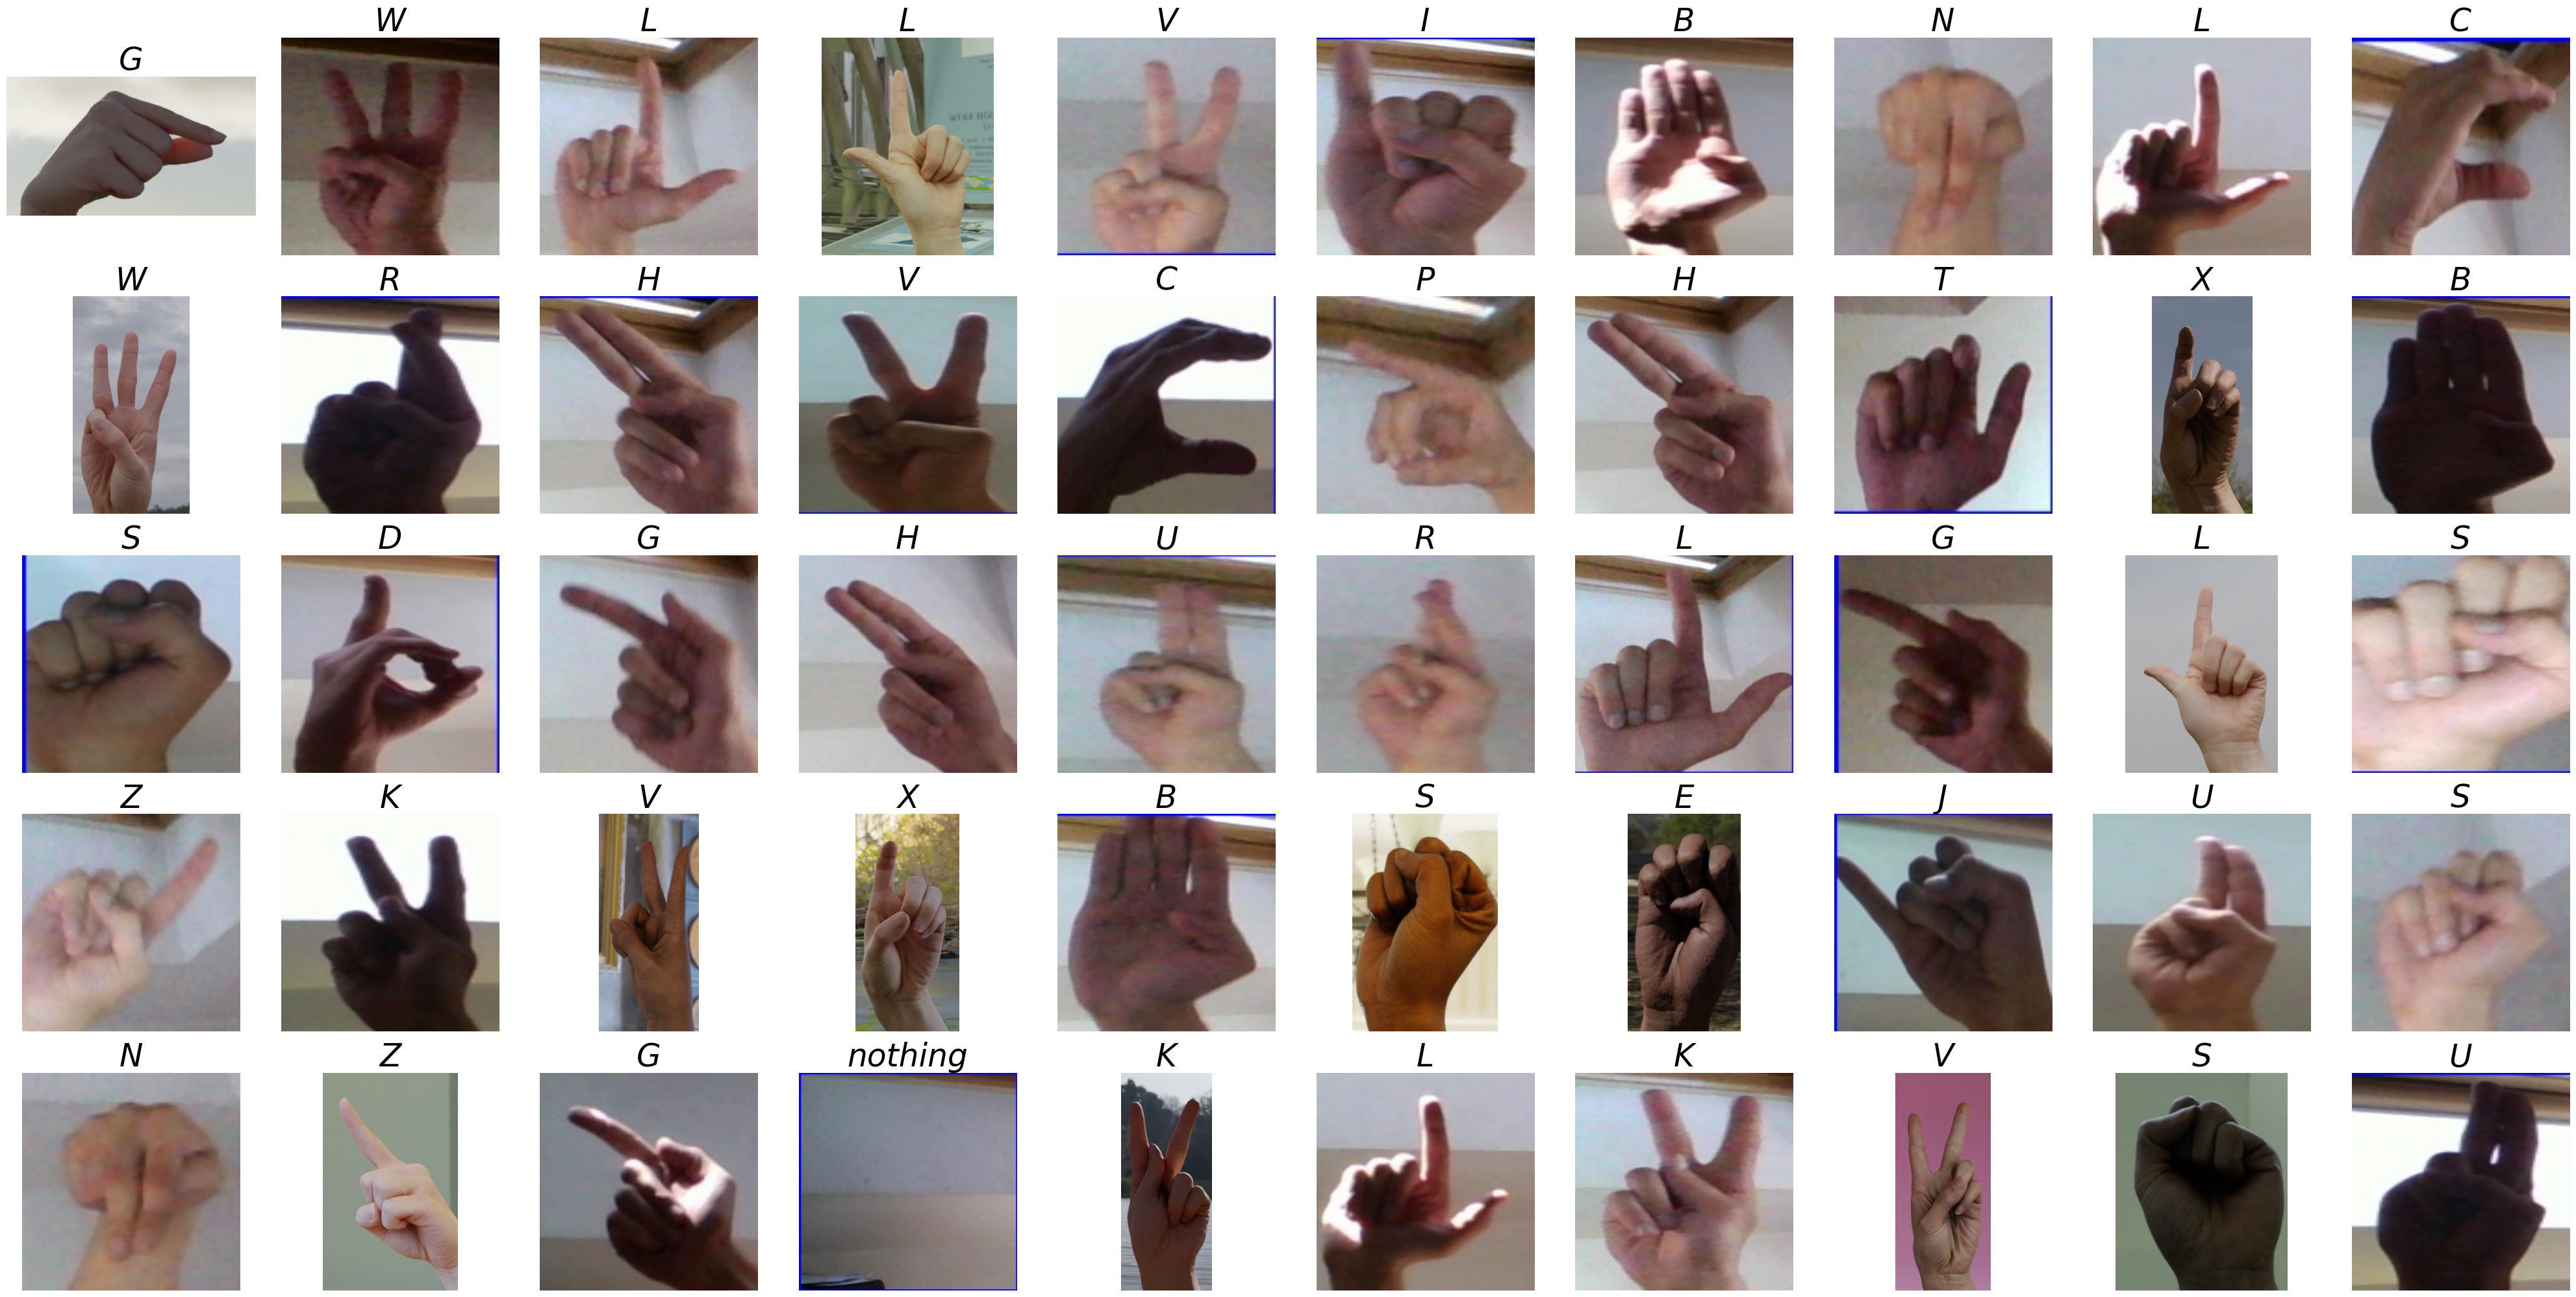

In [20]:
# Take 50 random images and viusalize them
sample_df = df.sample(50).reset_index(drop=True)

plt.figure(figsize=(40, 40))

for i in range(50):
    filepath = os.path.join(base_path, sample_df.filename.iloc[i])
    label = sample_df["category"].iloc[i]

    img = plt.imread(filepath)

    plt.subplot(10, 10, i + 1)
    plt.imshow(img)
    plt.title(label, fontsize=35, fontstyle='italic')
    plt.axis("off")

plt.tight_layout()
plt.show()

# 8: Analyzing Class Distribution


/tmp/ipython-input-301072663.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=uni, x='Category', y='Count', palette='icefire', width=0.4)


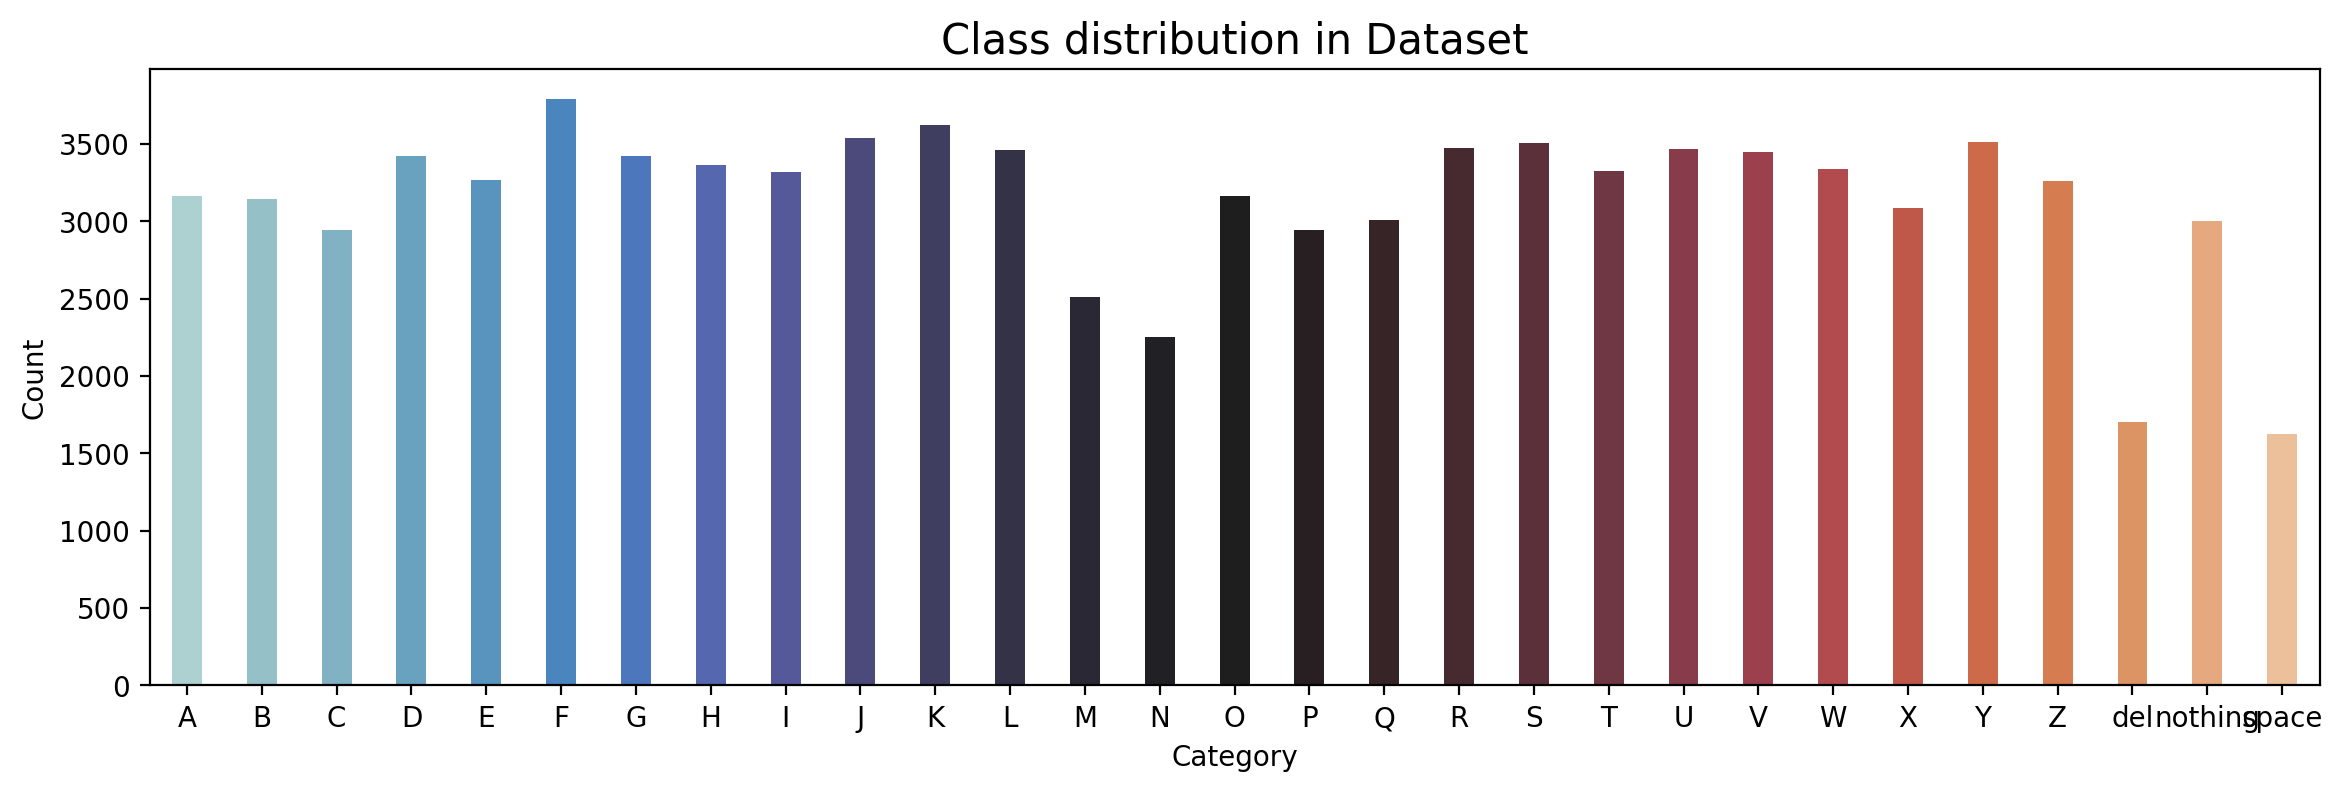

In [21]:
# Get count of all categories
category_counts = df['category'].value_counts().sort_index()

# Put into DataFrame to visualize better
uni = category_counts.reset_index()
uni.columns = ['Category', 'Count']

# Plot
plt.figure(figsize=(14,4), dpi=200)
sns.barplot(data=uni, x='Category', y='Count', palette='icefire', width=0.4)
plt.title('Class distribution in Dataset', fontsize=15)
plt.show()

All categories have equal count which is 3000

# 9: Split train data to train and validate




In [22]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(validation_split=0.2)

train_generator = datagen.flow_from_directory(
    base_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

validation_generator = datagen.flow_from_directory(
    base_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)



Found 72872 images belonging to 30 classes.
Found 18203 images belonging to 30 classes.


Make sure the split is correct

In [23]:
# Training class distribution
train_counts = np.bincount(train_generator.classes)
val_counts = np.bincount(validation_generator.classes)

print("Train class counts:", train_counts)
print("Validation class counts:", val_counts)

Train class counts: [   0 2532 2513 2355 2736 2614 3034 2738 2690 2653 2832 2898 2771 2011
 1803 2530 2353 2409 2779 2804 2663 2776 2760 2670 2467 2811 2609 1361
 2400 1300]
Validation class counts: [  0 632 628 588 684 653 758 684 672 663 707 724 692 502 450 632 588 602
 694 700 665 693 690 667 616 702 652 340 600 325]


# 10: Initialize the model

In [27]:
# To improve generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.2),
], name="data_augmentation")

base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
base_model.trainable = False
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(len(categories), activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint("best_model_stage1.h5", save_best_only=True, monitor="val_loss")
]

model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,334 (9.26 MB)

 Trainable params: 168,094 (656.62 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

#11: Fit model

In [28]:
classes = train_generator.classes
class_weights = compute_class_weight("balanced", classes=np.unique(classes), y=classes)
class_weights = dict(enumerate(class_weights))

In [29]:
asl_class = model.fit(train_generator,
                      validation_data= validation_generator,
                      epochs=10,
                      callbacks=callbacks,
                      class_weight=class_weights,
                      verbose = 1)

Epoch 1/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6771 - loss: 1.1637

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 191s 82ms/step - accuracy: 0.6771 - loss: 1.1635 - val_accuracy: 0.7504 - val_loss: 0.8023 - learning_rate: 0.0010
Epoch 2/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8611 - loss: 0.4479

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 174s 76ms/step - accuracy: 0.8611 - loss: 0.4479 - val_accuracy: 0.8008 - val_loss: 0.6438 - learning_rate: 0.0010
Epoch 3/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8768 - loss: 0.3914

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 176s 77ms/step - accuracy: 0.8768 - loss: 0.3914 - val_accuracy: 0.8324 - val_loss: 0.5426 - learning_rate: 0.0010
Epoch 4/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8853 - loss: 0.3625

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 174s 76ms/step - accuracy: 0.8853 - loss: 0.3625 - val_accuracy: 0.8542 - val_loss: 0.4740 - learning_rate: 0.0010
Epoch 5/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8877 - loss: 0.3510

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 175s 77ms/step - accuracy: 0.8877 - loss: 0.3510 - val_accuracy: 0.8750 - val_loss: 0.4149 - learning_rate: 0.0010
Epoch 6/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 184s 81ms/step - accuracy: 0.8963 - loss: 0.3243 - val_accuracy: 0.8595 - val_loss: 0.4540 - learning_rate: 0.0010
Epoch 7/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 174s 76ms/step - accuracy: 0.8998 - loss: 0.3106 - val_accuracy: 0.8628 - val_loss: 0.4360 - learning_rate: 0.0010
Epoch 8/10
1359/2278 ━━━━━━━━━━━━━━━━━━━━ 57s 63ms/step - accuracy: 0.9052 - loss: 0.3018

KeyboardInterrupt: 

# 12: FineTune model

In [ ]:
model.load_weights("best_model_stage1.h5")
# Unfreeze top layers of base_model
base_model.trainable = True
fine_tune_at = 120  # unfreeze last 120 layers (tune this)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with lower LR + label smoothing
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=3)]
)

callbacks_ft = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint("best_model_stage2.h5", save_best_only=True, monitor="val_loss")
]

# Fine-tune
history_ft = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=callbacks_ft,
    verbose=1
)


Epoch 1/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7710 - loss: 1.2785 - top_k_categorical_accuracy: 0.9226

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 246s 103ms/step - accuracy: 0.7710 - loss: 1.2784 - top_k_categorical_accuracy: 0.9226 - val_accuracy: 0.8857 - val_loss: 0.8858 - val_top_k_categorical_accuracy: 0.9730 - learning_rate: 1.0000e-05
Epoch 2/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9098 - loss: 0.8877 - top_k_categorical_accuracy: 0.9811

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 224s 98ms/step - accuracy: 0.9098 - loss: 0.8877 - top_k_categorical_accuracy: 0.9811 - val_accuracy: 0.9129 - val_loss: 0.8082 - val_top_k_categorical_accuracy: 0.9811 - learning_rate: 1.0000e-05
Epoch 3/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9395 - loss: 0.7869 - top_k_categorical_accuracy: 0.9891

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 224s 98ms/step - accuracy: 0.9395 - loss: 0.7869 - top_k_categorical_accuracy: 0.9891 - val_accuracy: 0.9430 - val_loss: 0.7343 - val_top_k_categorical_accuracy: 0.9878 - learning_rate: 1.0000e-05
Epoch 4/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9528 - loss: 0.7240 - top_k_categorical_accuracy: 0.9920

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 223s 98ms/step - accuracy: 0.9528 - loss: 0.7240 - top_k_categorical_accuracy: 0.9920 - val_accuracy: 0.9534 - val_loss: 0.7091 - val_top_k_categorical_accuracy: 0.9900 - learning_rate: 1.0000e-05
Epoch 5/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9650 - loss: 0.6701 - top_k_categorical_accuracy: 0.9945

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 225s 99ms/step - accuracy: 0.9650 - loss: 0.6701 - top_k_categorical_accuracy: 0.9945 - val_accuracy: 0.9647 - val_loss: 0.6606 - val_top_k_categorical_accuracy: 0.9918 - learning_rate: 1.0000e-05
Epoch 6/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9724 - loss: 0.6325 - top_k_categorical_accuracy: 0.9958

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 223s 98ms/step - accuracy: 0.9724 - loss: 0.6325 - top_k_categorical_accuracy: 0.9958 - val_accuracy: 0.9691 - val_loss: 0.6386 - val_top_k_categorical_accuracy: 0.9917 - learning_rate: 1.0000e-05
Epoch 7/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9774 - loss: 0.6047 - top_k_categorical_accuracy: 0.9970

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 224s 99ms/step - accuracy: 0.9774 - loss: 0.6047 - top_k_categorical_accuracy: 0.9970 - val_accuracy: 0.9746 - val_loss: 0.6125 - val_top_k_categorical_accuracy: 0.9926 - learning_rate: 1.0000e-05
Epoch 8/10
2278/2278 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9819 - loss: 0.5782 - top_k_categorical_accuracy: 0.9975

2278/2278 ━━━━━━━━━━━━━━━━━━━━ 228s 100ms/step - accuracy: 0.9819 - loss: 0.5782 - top_k_categorical_accuracy: 0.9975 - val_accuracy: 0.9781 - val_loss: 0.5910 - val_top_k_categorical_accuracy: 0.9935 - learning_rate: 1.0000e-05
Epoch 9/10
 464/2278 ━━━━━━━━━━━━━━━━━━━━ 2:38 87ms/step - accuracy: 0.9849 - loss: 0.5577 - top_k_categorical_accuracy: 0.9977